# Exercises in statistics

## Exercise 1

In this exercise we will use the penguins dataset (can be imported using the code `penguins_data = sns.load_dataset("penguins")`)

Please answer the following questions:

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as stats
from scipy.stats import mannwhitneyu

penguin_data = sns.load_dataset('penguins')

1. For the different species of penguins (Adelie, Chinstrap, and Gentoo), how many penguins are there of each species?

In [2]:
amount_of_penguins = penguin_data.species.value_counts()
print(amount_of_penguins)

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


2. For the different species of penguins (Adelie, Chinstrap, and Gentoo), is the body mass variable normally distributed?

species
Adelie       3700.0
Chinstrap    3700.0
Gentoo       5000.0
Name: body_mass_g, dtype: float64


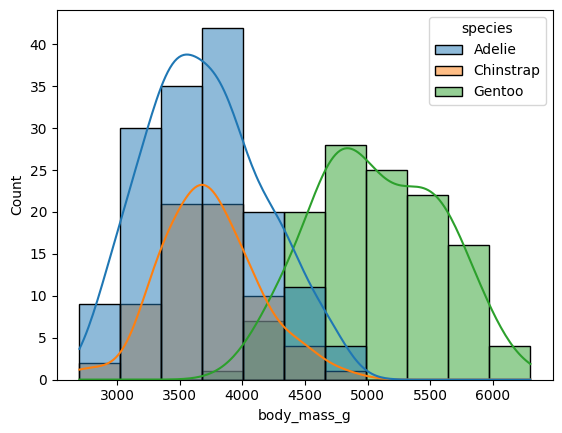

In [3]:
penguin_median = penguin_data.groupby('species')['body_mass_g'].median()
print(penguin_median)

sns.histplot(data=penguin_data, x='body_mass_g', hue='species', kde=True)
plt.show()

Based on the histogram and kde curves, the body mass of all three species appears 
approximately normally distributed. Adelie and Chinstrap a bit more than Gentoo, but Gentoo is still reasonably close to 
normal. 

3. Test whether there is a difference in body mass for Adelie penguins and Chinstrap penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.


In [4]:
adelie = penguin_data[penguin_data.species == 'Adelie'].body_mass_g.dropna()
chinstrap = penguin_data[penguin_data.species == 'Chinstrap'].body_mass_g.dropna()

result = stats.ttest_ind(adelie, chinstrap)
print(f"pvalue: {result.pvalue:.10f}")

pvalue: 0.6119084582


The p-value is 0.612, which is greater than 0.05. There is no significant difference in body mass between the two species.

4. Test whether there is a difference in body mass for Chinstrap penguins and Gentoo penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.


In [5]:
chinstrap = penguin_data[penguin_data.species == 'Chinstrap'].body_mass_g.dropna()
gentoo = penguin_data[penguin_data.species == 'Gentoo'].body_mass_g.dropna()

result = stats.ttest_ind(chinstrap, gentoo)
print(f"pvalue: {result.pvalue:.10f}")

pvalue: 0.0000000000


p =  0 < 0.05, so there is a statistically significant difference in body mass between Chinstrap and Gentoo penguins. Gentoo penguins are significantly heavier.

## Exercise 2

Load in the "fb_like_and_share.csv" data and answer the following questions:

In [6]:
fb_data = pd.read_csv("fb_like_and_share.csv", sep=";") 
print(fb_data.head())

    type  likes_count_fb  shares_count_fb
0  video             577                7
1  photo            2802               23
2  video             490               14
3   link             535               16
4  photo            1049               44


1. Is there a difference in the distribution of likes for photos and videos? Justify your choice of test(s).

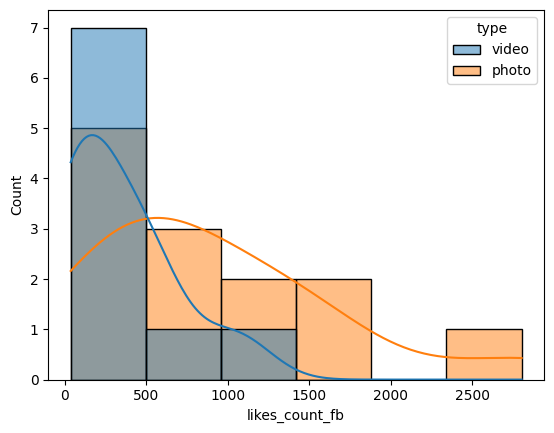

p-value: 0.04619850270741722
Mann-Whitney U test p-value: 0.0326063047830172


In [18]:
photos = fb_data[fb_data['type'] == 'photo']['likes_count_fb']
videos = fb_data[fb_data['type'] == 'video']['likes_count_fb']

sns.histplot(data=fb_data[fb_data['type'].isin(['photo','video'])], x='likes_count_fb', hue='type', kde=True)
plt.show()

ttest_result = stats.ttest_ind(photos, videos)
print(f"p-value: {ttest_result.pvalue}")

mannwhitney_result = mannwhitneyu(photos, videos)
print(f"Mann-Whitney U test p-value: {mannwhitney_result.pvalue}")

Both the ttest and mann-whitney u has a p-value under 0.05, which means there's evidence of a difference or relationship.

2. Is there a difference in the distribution of share counts for photos and videos? Justify your choice of test(s).

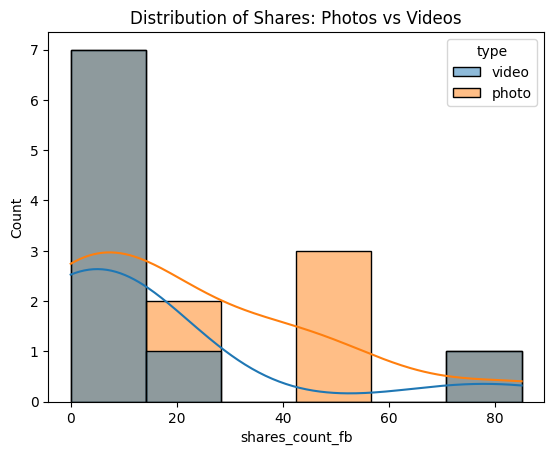

Mann-Whitney U statistic: 75.0, p-value: 0.28368085995763015


In [19]:
photo_shares = fb_data[fb_data['type'] == 'photo']['shares_count_fb']
video_shares = fb_data[fb_data['type'] == 'video']['shares_count_fb']

sns.histplot(data=fb_data[fb_data['type'].isin(['photo','video'])], x='shares_count_fb', hue='type', kde=True)
plt.title("Distribution of Shares: Photos vs Videos")
plt.show()

stat, p = stats.mannwhitneyu(photo_shares, video_shares)
print(f"Mann-Whitney U statistic: {stat}, p-value: {p}")

The histogram shows the data is right-skewed, so I use the Mann-Whitney U test. There is no difference in share counts between photos and videos. P > 0.05, so there is no significant difference in share counts between photos and videos. 

3. Perform an ANOVA test to test if there is a difference in means across type of posts for shares. Does it make sense to perform this ANOVA test?


In [20]:
anova_result = stats.f_oneway(
    fb_data[fb_data["type"] == "photo"]["shares_count_fb"],
    fb_data[fb_data["type"] == "video"]["shares_count_fb"],
    fb_data[fb_data["type"] == "status"]["shares_count_fb"],
    fb_data[fb_data["type"] == "link"]["shares_count_fb"]
)

print("ANOVA p-value:", anova_result.pvalue)

ANOVA p-value: 0.8565314091757276


p = 0.857 > 0.05, so we fail to reject H₀. It dosent make sense to use ANOVA, because it assumes the data is normally distributed, but share counts are heavily skewed. So the result should be taken with caution.

4. Is there actually a statistical significant difference in the distribution of share counts for any two groups?


In [10]:
post_types = fb_data["type"].unique()
for i in range(len(post_types)):
    for j in range(i + 1, len(post_types)):
        group1 = fb_data[fb_data["type"] == post_types[i]]["shares_count_fb"]
        group2 = fb_data[fb_data["type"] == post_types[j]]["shares_count_fb"]
        stat, p_value = mannwhitneyu(group1, group2)
        print(f"Comparison: {post_types[i]} vs {post_types[j]}")
        print(f"Mann-Whitney U statistic: {stat}, p-value: {p_value}\n")
        

Comparison: video vs photo
Mann-Whitney U statistic: 42.0, p-value: 0.28368085995763015

Comparison: video vs link
Mann-Whitney U statistic: 4.5, p-value: 0.04398211202214717

Comparison: video vs status
Mann-Whitney U statistic: 19.5, p-value: 0.40729365298228914

Comparison: photo vs link
Mann-Whitney U statistic: 22.0, p-value: 0.6913472082637717

Comparison: photo vs status
Mann-Whitney U statistic: 38.5, p-value: 1.0

Comparison: link vs status
Mann-Whitney U statistic: 12.0, p-value: 1.0



Only video vs. link shows a significant difference p ≈ 0.044 < 0.05. All other pairs show no significant difference.

## Exercise 3

Load in the data "energySoftware.csv" and answer the following questions:
1. Plot the distribution of CPU for each test type
2. Is there a difference in the CPU between bubblesort and bubblesort_ll? (note that the last name contains two small l's and not two capital i's) Justify your choice of test(s). 
3. Is there a difference in the CPU between bubblesort_func and bubblesort_ll2? Justify your choice of test(s). If there is a difference, how big is it?
4. When it comes to time, is there a difference between bubblesort and bubblesort_ll? Justify your choice of test(s).
5. Perform an ANOVA test to test if there is a difference in means across groups for time

Load in the data "energySoftware.csv"


In [11]:
es_data = pd.read_csv("energySoftware.csv",) 
print(es_data.head())

         test       PKG       CPU  nn nn2   time
0  bubblesort  0.010986  0.009155          3.165
1  bubblesort  0.013184  0.010925          3.069
2  bubblesort  0.015198  0.009399          2.617
3  bubblesort  0.010559  0.009583          2.572
4  bubblesort  0.009949  0.009949          2.671


1. Plot the distribution of CPU for each test type


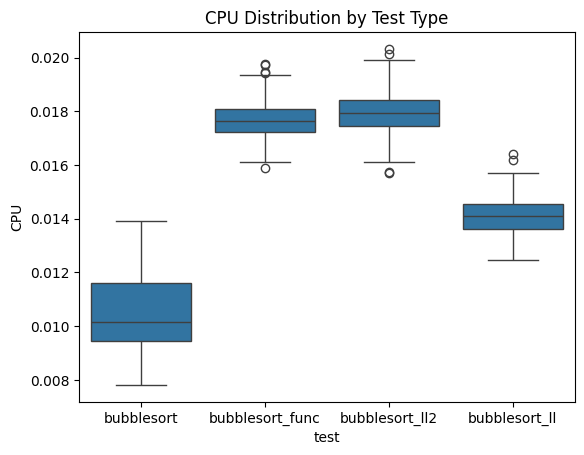

In [12]:
sns.boxplot(x="test", y="CPU", data=es_data)
plt.title("CPU Distribution by Test Type")
plt.show()

2. Is there a difference in the CPU between bubblesort and bubblesort_ll? (note that the last name contains two small l's and not two capital i's) Justify your choice of test(s). 


In [24]:
bs = es_data[es_data['test'] == 'bubblesort']['CPU']
bs_ll = es_data[es_data['test'] == 'bubblesort_ll']['CPU']

stat, p = stats.mannwhitneyu(bs, bs_ll)
print(f"p-value: {p:.10f}")

p-value: 0.0000000000


The p value is almost 0 (0 < 0.05) so there is very strong evidence of a difference of relationship. 

3. Is there a difference in the CPU between bubblesort_func and bubblesort_ll2? Justify your choice of test(s). If there is a difference, how big is it?


In [25]:
bs_func = es_data[es_data['test'] == 'bubblesort_func']['CPU']
bs_ll2 = es_data[es_data['test'] == 'bubblesort_ll2']['CPU']

stat, p = stats.mannwhitneyu(bs_func, bs_ll2)
print(f"p-value: {p}")

print(f"Median bubblesort_func: {bs_func.median():.6f}")
print(f"Median bubblesort_ll2: {bs_ll2.median():.6f}")
print(f"Median difference: {bs_func.median() - bs_ll2.median():.6f}")

p-value: 6.502153741813431e-07
Median bubblesort_func: 0.017639
Median bubblesort_ll2: 0.017944
Median difference: -0.000305


H₀: There is no difference in CPU between bubblesort_func and bubblesort_ll2.
H₁: There is a difference.
α = 0.05
p ≈ 0.0000007 < 0.05, so I reject H₀ — there is a significant difference in CPU between the two implementations. The difference is very small though, only -0.000305.

4. When it comes to time, is there a difference between bubblesort and bubblesort_ll? Justify your choice of test(s).


In [26]:
bs_time = es_data[es_data['test'] == 'bubblesort']['time']
bs_ll_time = es_data[es_data['test'] == 'bubblesort_ll']['time']

stat, p = stats.mannwhitneyu(bs_time, bs_ll_time)
print(f"p-value: {p}")

p-value: 0.00035855213302219286


p = 0.00035855213302219286 < 0.05, so I reject H₀. There is a significant difference in time between the two implementations.


5. Perform an ANOVA test to test if there is a difference in means across groups for time


In [16]:
anova_result = stats.f_oneway(
    es_data[es_data["test"] == "bubblesort"]["time"],
    es_data[es_data["test"] == "bubblesort_ll"]["time"],
    es_data[es_data["test"] == "bubblesort_func"]["time"],
    es_data[es_data["test"] == "bubblesort_ll2"]["time"]
)
print("ANOVA F-value:", anova_result.statistic)
print("ANOVA p-value:", anova_result.pvalue)


ANOVA F-value: 2556.3329354127823
ANOVA p-value: 0.0


From the ANOVA output above, the p-value is below 0.05, so H₀ is rejected.  
There is a statistically significant difference in mean time between at least two test groups.